In [1]:
from sunpy.net import Fido, attrs as a
from stixpy.net.client import STIXClient 

# Defining the time range for the GOES data
start_time = "2024-05-14T00:00:00"
end_time = "2024-05-15T00:00:00"


sci_query = Fido.search(a.Time(start_time, end_time), 
                        a.Instrument.stix,
                        a.stix.DataType.sci)
print(" Science data of STIX Files:", sci_query)

 Science data of STIX Files: Results from 1 Provider:

32 Results from the STIXClient:

       Start Time               End Time        Instrument Level DataType  DataProduct  Ver Request ID
----------------------- ----------------------- ---------- ----- -------- ------------- --- ----------
2024-05-14 00:27:08.000 2024-05-14 00:29:42.000       STIX    L1      SCI  sci-xray-cpd V02 2405140232
2024-05-14 00:34:14.000 2024-05-14 00:37:48.000       STIX    L1      SCI  sci-xray-cpd V02 2405141740
2024-05-14 00:54:12.000 2024-05-14 03:12:52.000       STIX    L1      SCI  sci-xray-cpd V02 2405144786
2024-05-14 00:54:36.000 2024-05-14 01:00:28.000       STIX    L1      SCI  sci-xray-cpd V02 2405141518
2024-05-14 01:09:35.000 2024-05-14 01:11:01.000       STIX    L1      SCI  sci-xray-cpd V02 2405146104
2024-05-14 01:40:09.000 2024-05-14 01:46:00.000       STIX    L1      SCI  sci-xray-cpd V02 2405148255
2024-05-14 01:58:27.000 2024-05-14 02:18:12.000       STIX    L1      SCI  sci-xray-cpd 

In [2]:
# Downloading the data
sci_files = Fido.fetch(sci_query)

Files Downloaded:   0%|          | 0/32 [00:00<?, ?file/s]

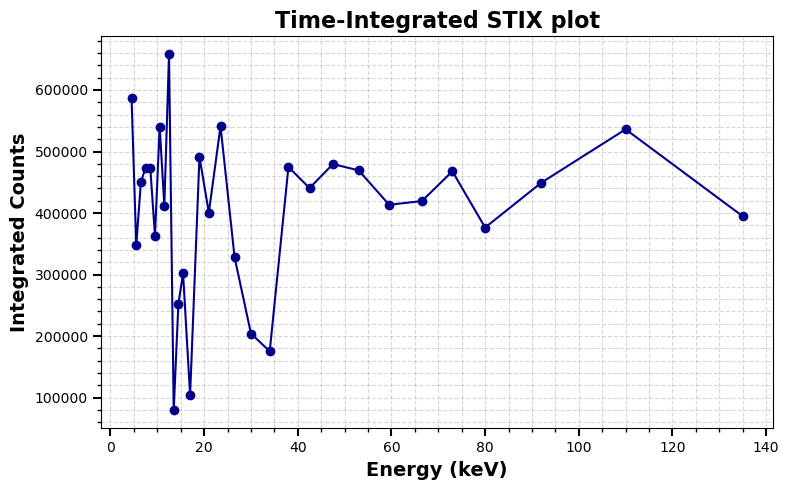

In [10]:
# Event-1

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time
from stixpy.product import Product
import matplotlib.dates as mdates  # For UTC time formatting



# Getting Compressed pixel data(cpd)

from stixpy.product import Product

sci_files = sorted(sci_files)

spec = Product(sci_files[6])  # Select the file

spec     # call to check the file details


# Define time range
start_time = Time('2024-05-14T02:02:45')
#end_time = Time('2024-05-14T02:05:15')
end_time = Time('2024-05-14T02:03:45')   # Filtered

# Extract time indices from spec
times = Time(spec.data['time'])
time_mask = (times >= start_time) & (times <= end_time)
time_indices = np.where(time_mask)[0]

#print(time_mask)
#print(time_indices)



# Extract energy bounds
e_low = spec.energies['e_low']
e_high = spec.energies['e_high']
energy_bin_centers = 0.5 * (e_low + e_high)
#print(energy_bin_centers.shape)


# Extract and sum counts: shape (time, energy, detector, pixel)

counts = spec.data['counts']  # [t, e, d, p]
#print(counts.shape)

time_filtered_counts = counts[time_indices, :, :, :]
#print(time_filtered_counts.shape)  

summed_counts = time_filtered_counts.sum(axis=(0, 2, 3))
#print(summed_counts.shape)

summed_counts = summed_counts[:31]  # Trim to match energy_bin_centers
#print(summed_counts.shape)


# Plot the 1D spectrogram
plt.figure(figsize=(8, 5))
plt.plot(energy_bin_centers, summed_counts.value, marker='o', linestyle='-', color='darkblue')
plt.xlabel("Energy (keV)", fontsize=14, fontweight='bold')
plt.ylabel("Integrated Counts", fontsize=14, fontweight='bold')
plt.title("Time-Integrated STIX plot", fontsize=16, fontweight='bold')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.minorticks_on()
plt.tick_params(axis='both', which='major', direction='out', length=6, width=1.5)
plt.tick_params(axis='both', which='minor', direction='out', length=3, width=1)
plt.tight_layout()
plt.show()

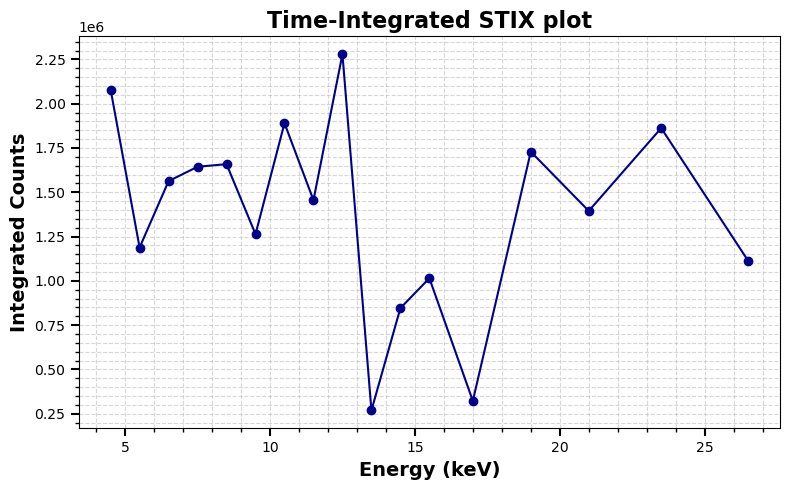

In [17]:
# Event-2

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time
from stixpy.product import Product
import matplotlib.dates as mdates  # For UTC time formatting



# Getting Compressed pixel data(cpd)

from stixpy.product import Product

sci_files = sorted(sci_files)

spec = Product(sci_files[12])  # Select the file

spec     # call to check the file details


# Define time range
start_time = Time('2024-05-14T12:42:30')
#end_time = Time('2024-05-14T12:49:30')
end_time = Time('2024-05-14T12:46:55')  # Filtered

# Extract time indices from spec
times = Time(spec.data['time'])
time_mask = (times >= start_time) & (times <= end_time)
time_indices = np.where(time_mask)[0]

#print(time_mask)
#print(time_indices)



# Extract energy bounds
e_low = spec.energies['e_low']
e_high = spec.energies['e_high']
energy_bin_centers = 0.5 * (e_low + e_high)
#print(energy_bin_centers.shape)


# Extract and sum counts: shape (time, energy, detector, pixel)

counts = spec.data['counts']  # [t, e, d, p]
#print(counts.shape)

time_filtered_counts = counts[time_indices, :, :, :]
#print(time_filtered_counts.shape)  

summed_counts = time_filtered_counts.sum(axis=(0, 2, 3))
#print(summed_counts.shape)

summed_counts = summed_counts[:17]  # Trim to match energy_bin_centers
#print(summed_counts.shape)


# Plot the 1D spectrogram
plt.figure(figsize=(8, 5))
plt.plot(energy_bin_centers, summed_counts.value, marker='o', linestyle='-', color='darkblue')
plt.xlabel("Energy (keV)", fontsize=14, fontweight='bold')
plt.ylabel("Integrated Counts", fontsize=14, fontweight='bold')
plt.title("Time-Integrated STIX plot", fontsize=16, fontweight='bold')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.minorticks_on()
plt.tick_params(axis='both', which='major', direction='out', length=6, width=1.5)
plt.tick_params(axis='both', which='minor', direction='out', length=3, width=1)
plt.tight_layout()
plt.show()

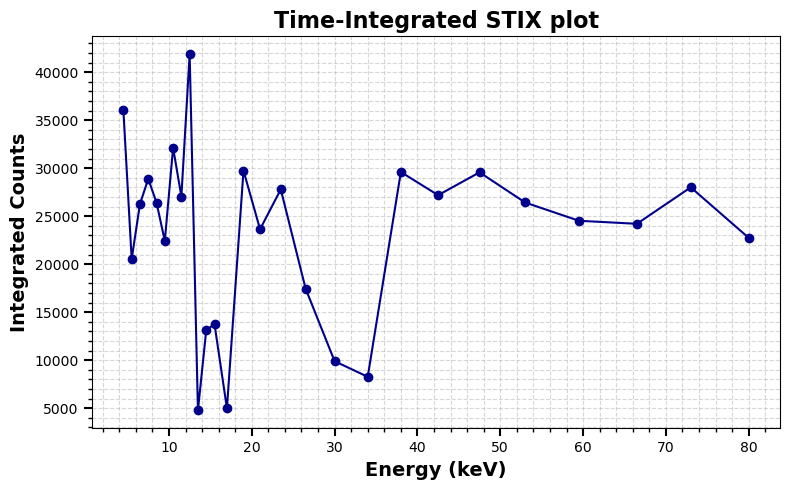

In [18]:
# Event-3

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time
from stixpy.product import Product
import matplotlib.dates as mdates  # For UTC time formatting



# Getting Compressed pixel data(cpd)

from stixpy.product import Product

sci_files = sorted(sci_files)

spec = Product(sci_files[16])  # Select the file

spec     # call to check the file details


# Define time range
start_time = Time('2024-05-14T15:18:00')
end_time = Time('2024-05-14T15:19:30')


# Extract time indices from spec
times = Time(spec.data['time'])
time_mask = (times >= start_time) & (times <= end_time)
time_indices = np.where(time_mask)[0]

#print(time_mask)
#print(time_indices)



# Extract energy bounds
e_low = spec.energies['e_low']
e_high = spec.energies['e_high']
energy_bin_centers = 0.5 * (e_low + e_high)
#print(energy_bin_centers.shape)


# Extract and sum counts: shape (time, energy, detector, pixel)

counts = spec.data['counts']  # [t, e, d, p]
#print(counts.shape)

time_filtered_counts = counts[time_indices, :, :, :]
#print(time_filtered_counts.shape)  

summed_counts = time_filtered_counts.sum(axis=(0, 2, 3))
#print(summed_counts.shape)

summed_counts = summed_counts[:27]  # Trim to match energy_bin_centers
#print(summed_counts.shape)


# Plot the 1D spectrogram
plt.figure(figsize=(8, 5))
plt.plot(energy_bin_centers, summed_counts.value, marker='o', linestyle='-', color='darkblue')
plt.xlabel("Energy (keV)", fontsize=14, fontweight='bold')
plt.ylabel("Integrated Counts", fontsize=14, fontweight='bold')
plt.title("Time-Integrated STIX plot", fontsize=16, fontweight='bold')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.minorticks_on()
plt.tick_params(axis='both', which='major', direction='out', length=6, width=1.5)
plt.tick_params(axis='both', which='minor', direction='out', length=3, width=1)
plt.tight_layout()
plt.show()

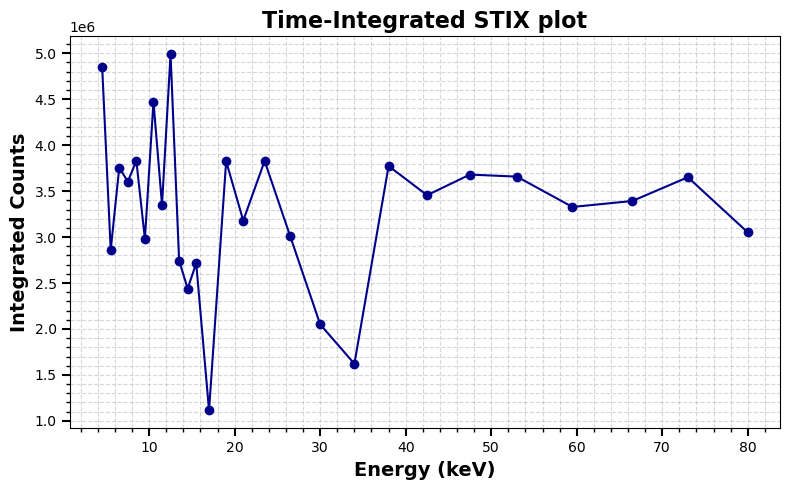

In [20]:
# Event-4

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time
from stixpy.product import Product
import matplotlib.dates as mdates  # For UTC time formatting



# Getting Compressed pixel data(cpd)

from stixpy.product import Product

sci_files = sorted(sci_files)

spec = Product(sci_files[19])  # Select the file

spec     # call to check the file details


# Define time range
start_time = Time('2024-05-14T16:43:30')
end_time = Time('2024-05-14T16:51:30')


# Extract time indices from spec
times = Time(spec.data['time'])
time_mask = (times >= start_time) & (times <= end_time)
time_indices = np.where(time_mask)[0]

#print(time_mask)
#print(time_indices)



# Extract energy bounds
e_low = spec.energies['e_low']
e_high = spec.energies['e_high']
energy_bin_centers = 0.5 * (e_low + e_high)
#print(energy_bin_centers.shape)


# Extract and sum counts: shape (time, energy, detector, pixel)

counts = spec.data['counts']  # [t, e, d, p]
#print(counts.shape)

time_filtered_counts = counts[time_indices, :, :, :]
#print(time_filtered_counts.shape)  

summed_counts = time_filtered_counts.sum(axis=(0, 2, 3))
#print(summed_counts.shape)

summed_counts = summed_counts[:27]  # Trim to match energy_bin_centers
#print(summed_counts.shape)


# Plot the 1D spectrogram
plt.figure(figsize=(8, 5))
plt.plot(energy_bin_centers, summed_counts.value, marker='o', linestyle='-', color='darkblue')
plt.xlabel("Energy (keV)", fontsize=14, fontweight='bold')
plt.ylabel("Integrated Counts", fontsize=14, fontweight='bold')
plt.title("Time-Integrated STIX plot", fontsize=16, fontweight='bold')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.minorticks_on()
plt.tick_params(axis='both', which='major', direction='out', length=6, width=1.5)
plt.tick_params(axis='both', which='minor', direction='out', length=3, width=1)
plt.tight_layout()
plt.show()

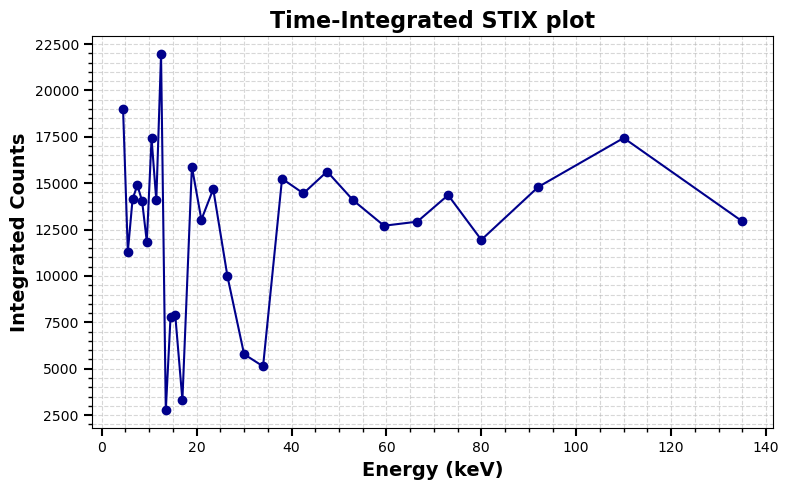

In [22]:
# Event-5

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time
from stixpy.product import Product
import matplotlib.dates as mdates  # For UTC time formatting



# Getting Compressed pixel data(cpd)

from stixpy.product import Product

sci_files = sorted(sci_files)

spec = Product(sci_files[23])  # Select the file

spec     # call to check the file details


# Define time range
start_time = Time('2024-05-14T18:03:10')
end_time = Time('2024-05-14T18:04:00')


# Extract time indices from spec
times = Time(spec.data['time'])
time_mask = (times >= start_time) & (times <= end_time)
time_indices = np.where(time_mask)[0]

#print(time_mask)
#print(time_indices)



# Extract energy bounds
e_low = spec.energies['e_low']
e_high = spec.energies['e_high']
energy_bin_centers = 0.5 * (e_low + e_high)
#print(energy_bin_centers.shape)


# Extract and sum counts: shape (time, energy, detector, pixel)

counts = spec.data['counts']  # [t, e, d, p]
#print(counts.shape)

time_filtered_counts = counts[time_indices, :, :, :]
#print(time_filtered_counts.shape)  

summed_counts = time_filtered_counts.sum(axis=(0, 2, 3))
#print(summed_counts.shape)

summed_counts = summed_counts[:-1]  # Trim to match energy_bin_centers
#print(summed_counts.shape)


# Plot the 1D spectrogram
plt.figure(figsize=(8, 5))
plt.plot(energy_bin_centers, summed_counts.value, marker='o', linestyle='-', color='darkblue')
plt.xlabel("Energy (keV)", fontsize=14, fontweight='bold')
plt.ylabel("Integrated Counts", fontsize=14, fontweight='bold')
plt.title("Time-Integrated STIX plot", fontsize=16, fontweight='bold')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.minorticks_on()
plt.tick_params(axis='both', which='major', direction='out', length=6, width=1.5)
plt.tick_params(axis='both', which='minor', direction='out', length=3, width=1)
plt.tight_layout()
plt.show()